# Part 1: Selecting and analyzing the dataset

I have chosen a simple dataset, which you can find in the following [link](https://archive.ics.uci.edu/dataset/186/wine+quality)
This dataset has variables about the wine and its quality
it has a total of 11 features, where one of them is the quality, which is measured from 1 to 10, where 1 is bad and 10 really good

In [203]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 
  
# metadata 
print(wine_quality.metadata) 

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [2]:
# variable information 
print(wine_quality.variables) 

                    name     role         type demographic  \
0          fixed_acidity  Feature   Continuous        None   
1       volatile_acidity  Feature   Continuous        None   
2            citric_acid  Feature   Continuous        None   
3         residual_sugar  Feature   Continuous        None   
4              chlorides  Feature   Continuous        None   
5    free_sulfur_dioxide  Feature   Continuous        None   
6   total_sulfur_dioxide  Feature   Continuous        None   
7                density  Feature   Continuous        None   
8                     pH  Feature   Continuous        None   
9              sulphates  Feature   Continuous        None   
10               alcohol  Feature   Continuous        None   
11               quality   Target      Integer        None   
12                 color    Other  Categorical        None   

               description units missing_values  
0                     None  None             no  
1                     None  Non

In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
dtypes: float64(11)
memory usage: 558.5 KB


In [4]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   quality  6497 non-null   int64
dtypes: int64(1)
memory usage: 50.9 KB


In [5]:
X.isna().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

In [6]:
y.isna().sum()

quality    0
dtype: int64

In [7]:
y.tail

<bound method NDFrame.tail of       quality
0           5
1           5
2           5
3           6
4           5
...       ...
6492        6
6493        5
6494        6
6495        7
6496        6

[6497 rows x 1 columns]>

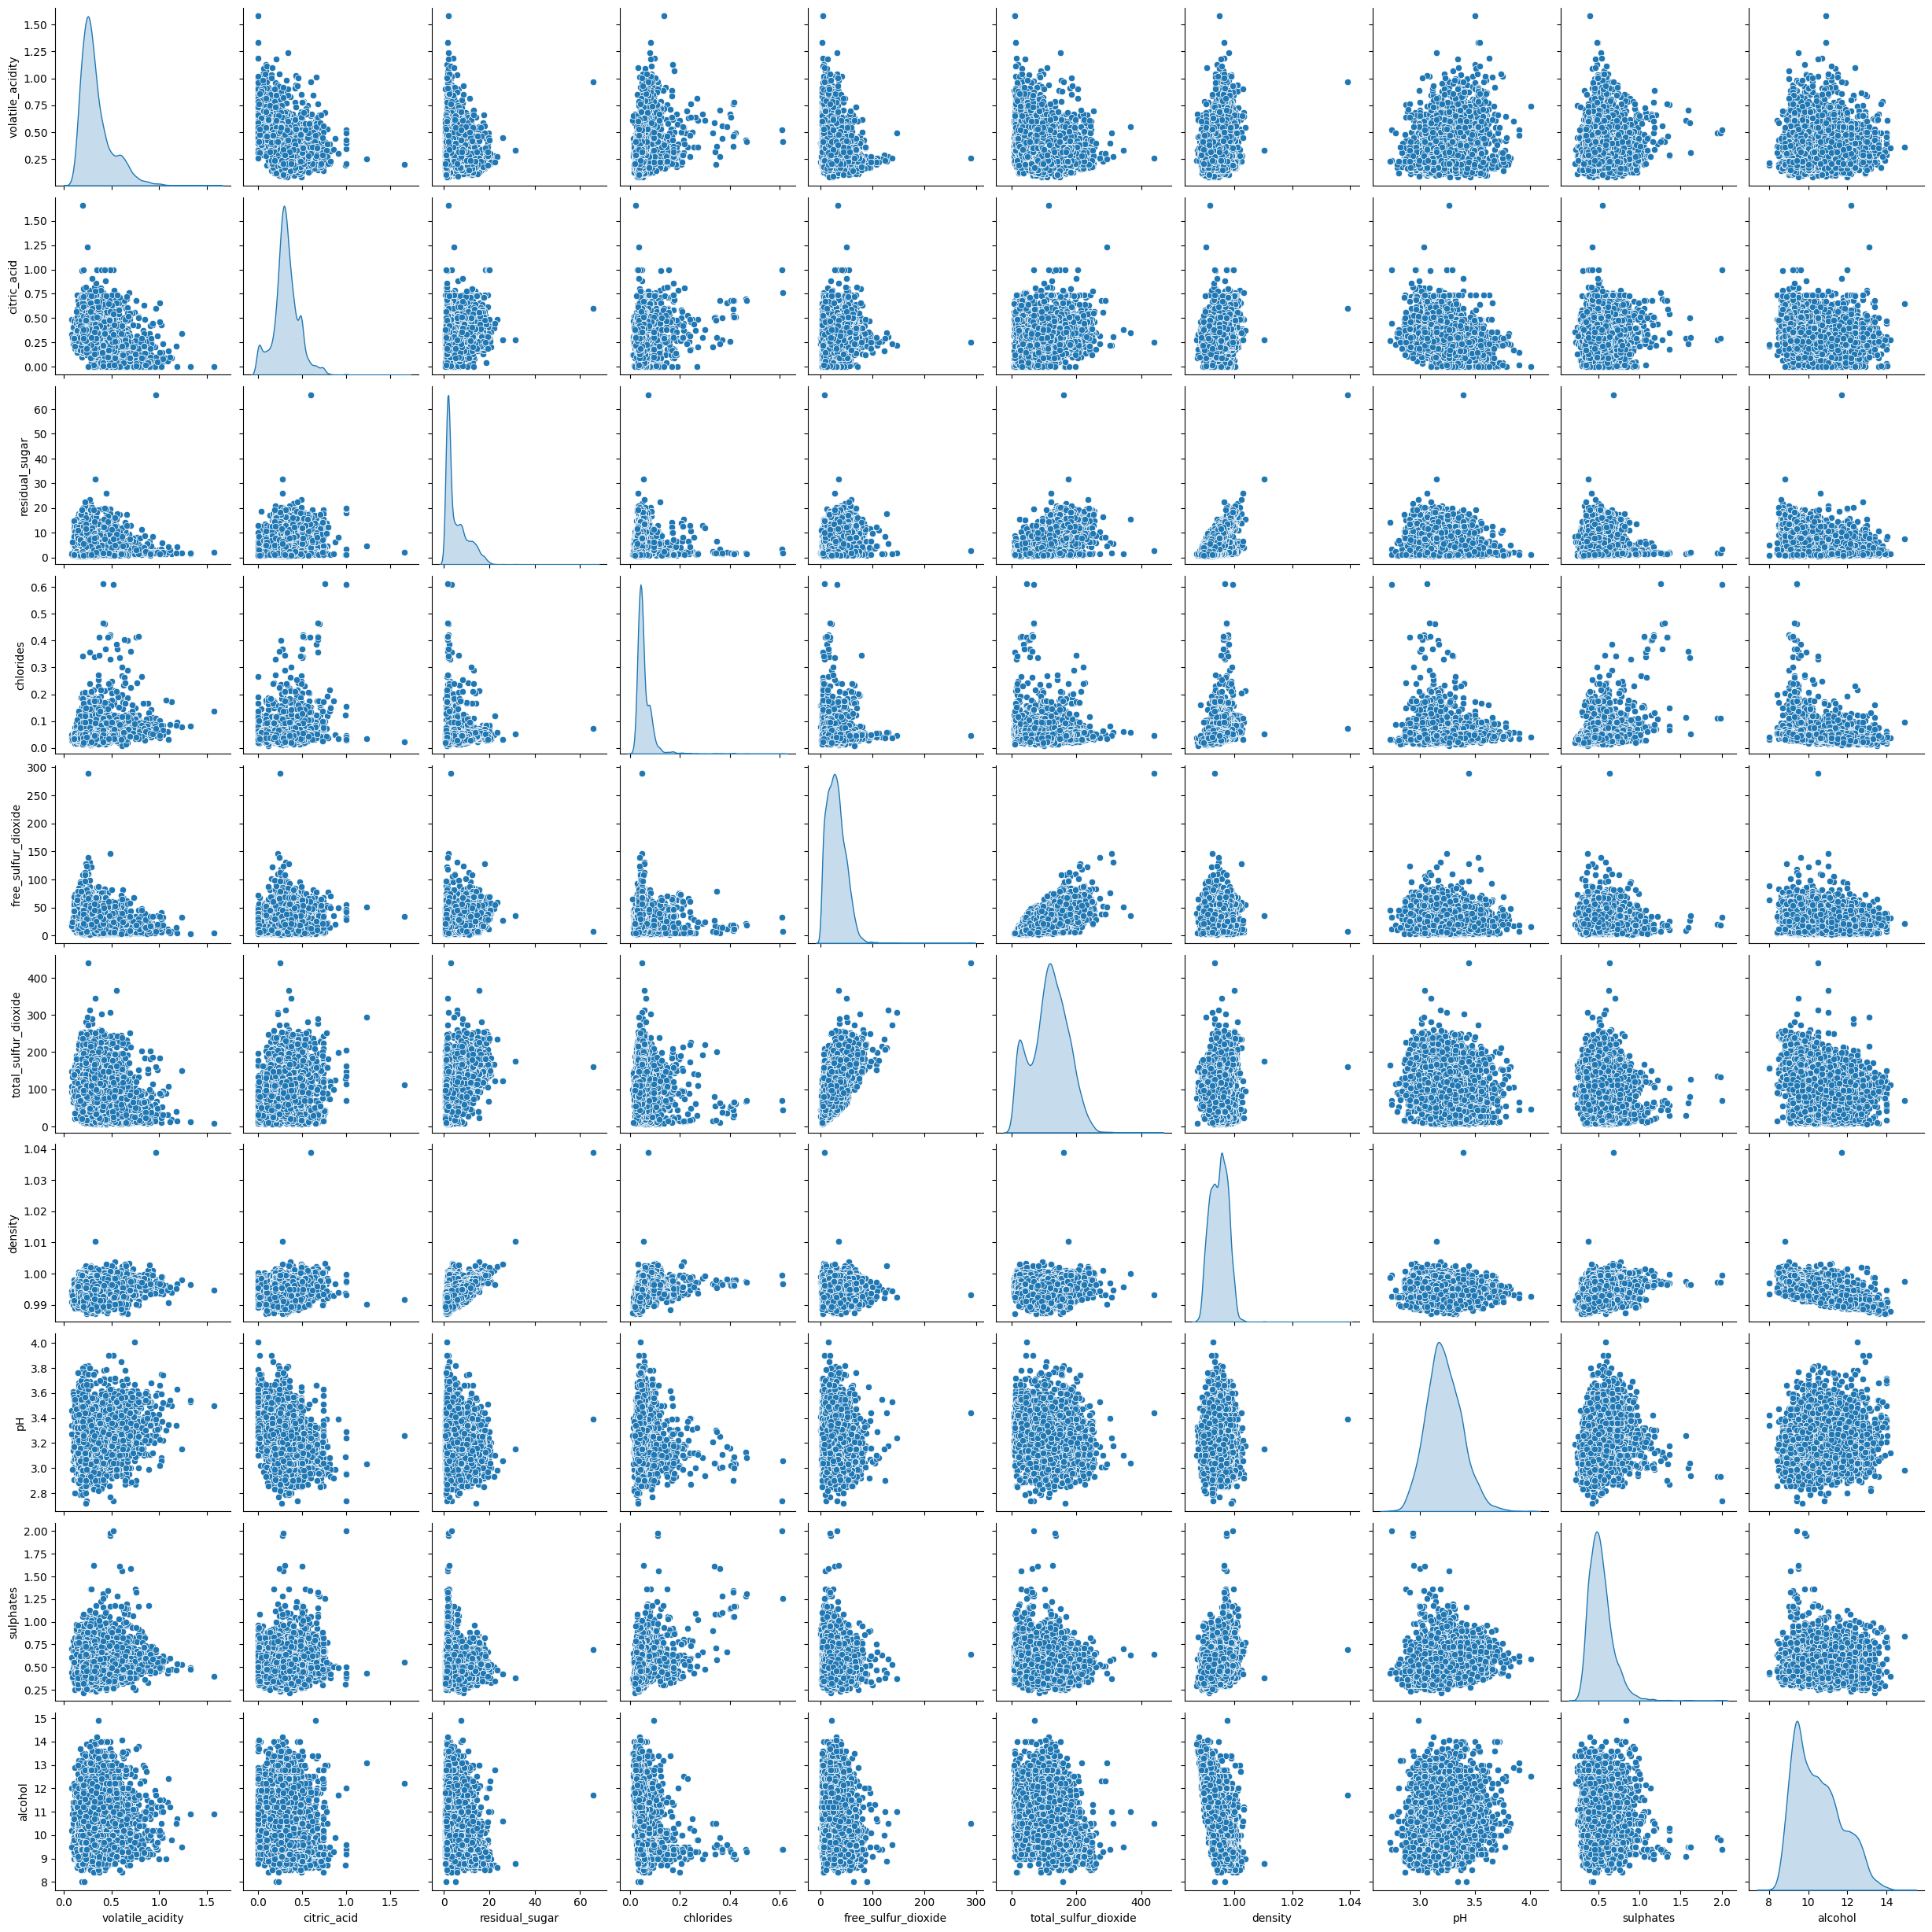

In [10]:
sns.pairplot(X[[
    'volatile_acidity', 
    'citric_acid', 
    'residual_sugar', 
    'chlorides',
    'free_sulfur_dioxide', 
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    
    
]], diag_kind='kde')


In [11]:
X.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile_acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric_acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual_sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free_sulfur_dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total_sulfur_dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [12]:
y.describe().transpose()[['mean', 'std']]

,mean,std
quality,5.818378,0.873255


## Regression using XGBoost

In [124]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(X)

In [133]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(normalized_data, y, test_size=0.2, random_state=42)

# Create an XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

# Predict numeric values on the test data
predictions = model.predict(X_test)

In [134]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.4064270853996277


## Regression using Linear Regression

In [143]:
X_train, X_test, y_train, y_test = train_test_split(normalized_data, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import  mean_squared_error, mean_absolute_error, r2_score

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Squared Error (MSE): 0.5466964419594447
R² Score: 0.2597673129771393


## Regression using a NN with tensorflow
https://github.com/YanSte/DNN-Wine-Prediction/blob/main/dnn-wine-wine-quality-prediction-with-dnn.ipynb

In [144]:
shape = X_train.shape[1]

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(shape, name="InputLayer"))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n1'))
model.add(tf.keras.layers.Dense(64, activation='relu', name='Dense_n2'))
model.add(tf.keras.layers.Dense(1, name='Output'))

model.compile(
    optimizer = 'rmsprop',
    loss = 'mse',
    metrics = ['mae', 'mse']
)

In [145]:
batch_size = 16
epochs = 50
seed = 123
fit_verbosity = 1

In [146]:
history = model.fit(X_train,
                    y_train,
                    epochs          = epochs,
                    batch_size      = batch_size,
                    verbose         = fit_verbosity,
                    validation_data = (X_test, y_test)
                   )

Epoch 1/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - loss: 2.9032 - mae: 1.0886 - mse: 2.9032 - val_loss: 0.6413 - val_mae: 0.6125 - val_mse: 0.6413
Epoch 2/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.6255 - mae: 0.6119 - mse: 0.6255 - val_loss: 0.6515 - val_mae: 0.6222 - val_mse: 0.6515
Epoch 3/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step - loss: 0.5927 - mae: 0.5981 - mse: 0.5927 - val_loss: 0.5699 - val_mae: 0.5787 - val_mse: 0.5699
Epoch 4/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 608us/step - loss: 0.5787 - mae: 0.5881 - mse: 0.5787 - val_loss: 0.5511 - val_mae: 0.5663 - val_mse: 0.5511
Epoch 5/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 555us/step - loss: 0.5677 - mae: 0.5846 - mse: 0.5677 - val_loss: 0.6018 - val_mae: 0.6026 - val_mse: 0.6018
Epoch 6/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step - loss: 0.5622 - mae: 0.5805 - mse: 0.5622 - val_loss: 0.5982 - val_mae: 0.6033 - val_mse: 0.5982
Epoch 7/50
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 0.5596 - mae: 0.5801 - mse

Text(0.5, 0, 'epochs')

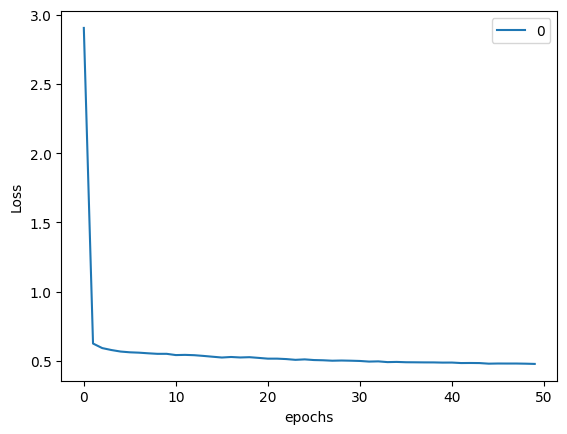

In [148]:
pd.DataFrame(history.history['loss']).plot()
plt.ylabel("Loss")
plt.xlabel("epochs")

In [178]:
y_new_pred = predict(X_test[:5], W1, b1, W2, b2)
y_new_pred

array([[6.10847868],
       [5.79189637],
       [5.9878873 ],
       [5.74126186],
       [5.69983307]])

In [180]:
y_test[:5]

,quality
3103,8
1419,5
4761,7
4690,6
4032,6


## NN from scratch

In [308]:
class NeuralNet:
    def __init__(
        self, 
        layers, 
        n_epochs=100, 
        lr=0.01, 
        momentum=0.0,
        activation='sigmoid', 
        val_percent=0.0, 
        random_state=None,
        X = [],
        y = [],
    ):
        """
        n_layers: int -> number of layers (including input and output)
        n_units: list/array length n_layers -> units per layer [n0, n1, ..., nL-1]
        n_epochs: number of epochs for training
        lr: learning rate
        momentum: momentum term (0..1)
        activation: string -> 'sigmoid' | 'relu' | 'tanh' | 'linear' (used for hidden and output)
        val_percent: fraction (0..1) of training set to use as validation
        """

        self.L = len(layers)
        self.n = layers.copy()
        self.epochs = int(n_epochs)
        self.lr = float(lr)
        self.momentum = float(momentum)
        self.fact = activation.lower()
        self.val_percent = float(val_percent)
        self.random_state = random_state
        self.batch_size = 1000
        self.X = X
        self.y = y
        
        # Weight and bias initialization
        self.W = []
        self.B = []

        for i in range(len(layers)-1):
            w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2 / layers[i])
            b = np.zeros((1, layers[i+1]))
            self.W.append(w)
            self.B.append(b)
            
        # n_features = X.shape[1]
        # self.b = np.random.randn(1, n_features) * 0.01

        # # self.xi = [] I dont know what to do with this
        # # for lay in range(self.L):
        # #   self.xi.append(np.zeros(layers[lay]))
    
        # self.w = []
        # for lay in range(1, self.L):
        #     shape = (n_features, layers[lay - 1])
        #     self.w.append(np.random.randn(*shape) * 0.01)
            
        # self.w.append(np.random.randn(1, 1) * 0.01) 

    def fit(self):

        for epoch in range(0, self.epochs):
            n_rows = self.X.shape[0]
            n_iterations = n_rows // self.batch_size 
            for iteration in range(1, n_iterations + 1):
                #forward propagation
                if iteration == 1 :
                    start = 0
                else:
                    start = (self.batch_size * iteration) - self.batch_size
                end = iteration * self.batch_size
                
                x = X_train[start:end]
                print(start, end)
            
                Z1 = np.dot(x, self.w[0]) + self.b
                # we apply relu for now, but we need to have more activiation functions
                A1 = np.maximum(0, Z1)

                


layers = [11, 9, 5, 1]
nn = NeuralNet(layers, 400, 0.01, 0, 'relu', 0, None, X_train, y_train)


In [312]:
len(nn.W)

3

In [319]:
nn.W[1].shape

(9, 5)